# Task 3: Basic Data Visualization

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
df = pd.read_csv('cleaned_stock_prices.csv')

In [10]:
df['date'] = pd.to_datetime(df['date'])

In [11]:
df.head()

,symbol,date,open,high,low,close,volume
0,AAL,2014-01-02,25.0700,25.8200,25.0600,25.3600,8998943
1,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957
2,AAP,2014-01-02,110.3600,111.8800,109.2900,109.7400,542711
3,ABBV,2014-01-02,52.1200,52.3300,51.5200,51.9800,4569061
4,ABC,2014-01-02,70.1100,70.2300,69.4800,69.8900,1148391


# Chart 1 —  Bar Chart

## Note: Because we have 505 different stock symbols, putting all 505 stocks on one bar chart would be messy. Instead, let's select the top 10 stocks by average closing price.

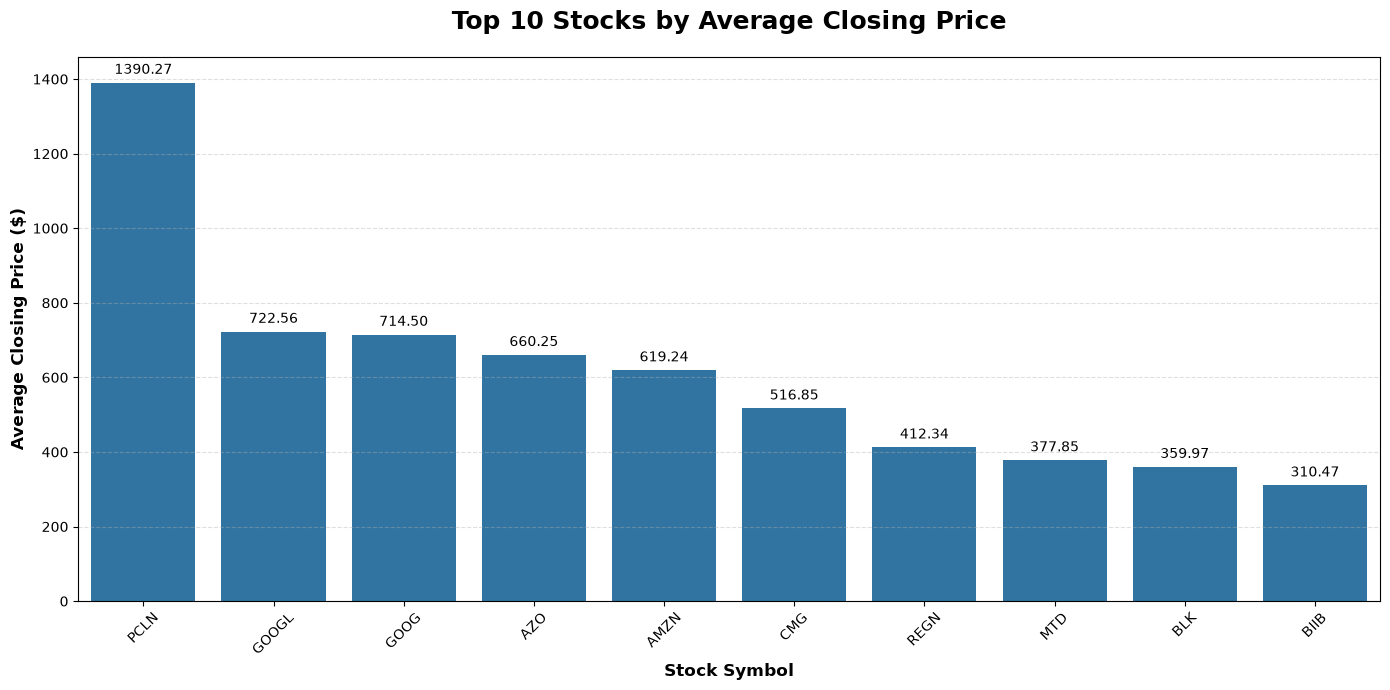

In [12]:
# Calculating the average closing price for each stock
top_10_stocks = (df.groupby('symbol')['close']
    .mean()
    .sort_values(ascending=False)
    .head(10))

# Creating the figure
plt.figure(figsize=(14, 7))

# Creating the bar chart 
ax = sns.barplot(    x=top_10_stocks.index,
    y=top_10_stocks.values)

# Title
plt.title('Top 10 Stocks by Average Closing Price',
    fontsize=18,
    fontweight='bold',
    pad=20)

# Axis labels
plt.xlabel('Stock Symbol',
    fontsize=12,
    fontweight='bold')

plt.ylabel('Average Closing Price ($)',
    fontsize=12,
    fontweight='bold')

# Rotate stock symbols
plt.xticks(rotation=45)

# Add values above bars
for container in ax.containers:
    ax.bar_label(container,
        fmt='%.2f',
        padding=4,
        fontsize=10)

# Grid
plt.grid(axis='y',
    linestyle='--',
    alpha=0.4)

# Remove vertical grid
plt.grid(axis='x', visible=False)

# Improve spacing
plt.tight_layout()

plt.savefig('top_10_stocks_average_closing_price.png',
    dpi=300,
    bbox_inches='tight')

plt.show()

## Chart 2 — Line Chart

## Note: since we have over 505 unique stocks, the line chart will be displaying the actual closing price movement over time for the AAPL stock. 

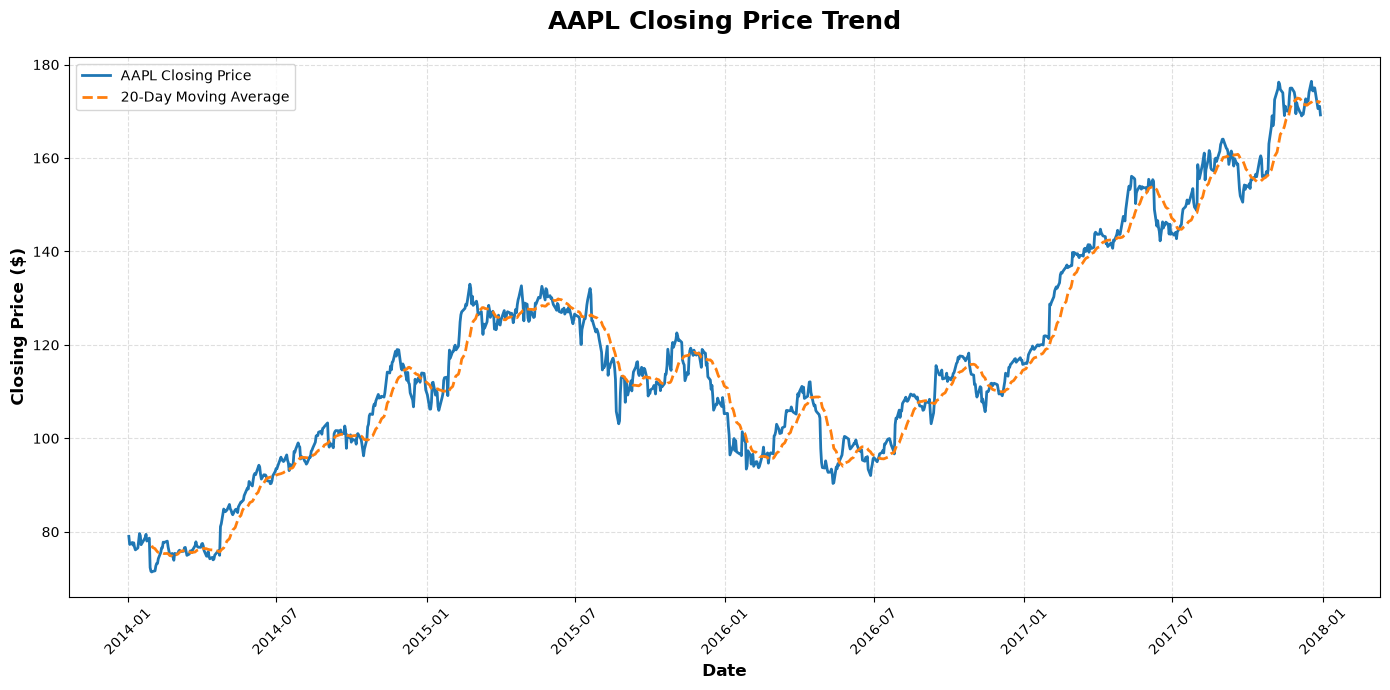

In [13]:
# Selecting AAPL
aapl = df[df['symbol'] == 'AAPL'].copy()

# Sort by date
aapl = aapl.sort_values('date')

# Calculate 20-day moving average
aapl['MA20'] = aapl['close'].rolling(window=20).mean()

# Create figure
plt.figure(figsize=(14, 7))

# Closing price
plt.plot(
    aapl['date'],
    aapl['close'],
    linewidth=2,
    label='AAPL Closing Price')

# 20-day moving average
plt.plot(
    aapl['date'],
    aapl['MA20'],
    linewidth=2,
    linestyle='--',
    label='20-Day Moving Average')

# Title
plt.title(
    'AAPL Closing Price Trend',
    fontsize=18,
    fontweight='bold',
    pad=20)

# Axis labels
plt.xlabel(
    'Date',
    fontsize=12,
    fontweight='bold')

plt.ylabel(
    'Closing Price ($)',
    fontsize=12,
    fontweight='bold')

# Rotate dates
plt.xticks(rotation=45)

# Legend
plt.legend(
    loc='upper left',
    fontsize=10,
    frameon=True)

# Grid
plt.grid(
    True,
    linestyle='--',
    alpha=0.4)

# Layout
plt.tight_layout()

plt.savefig(
    'AAPL_closing_price_trend.png',
    dpi=300,
    bbox_inches='tight')

plt.show()

## Chart 3 — Scatter Plot

## Note: The chart examines the relationship between AAPL's daily high price and closing price

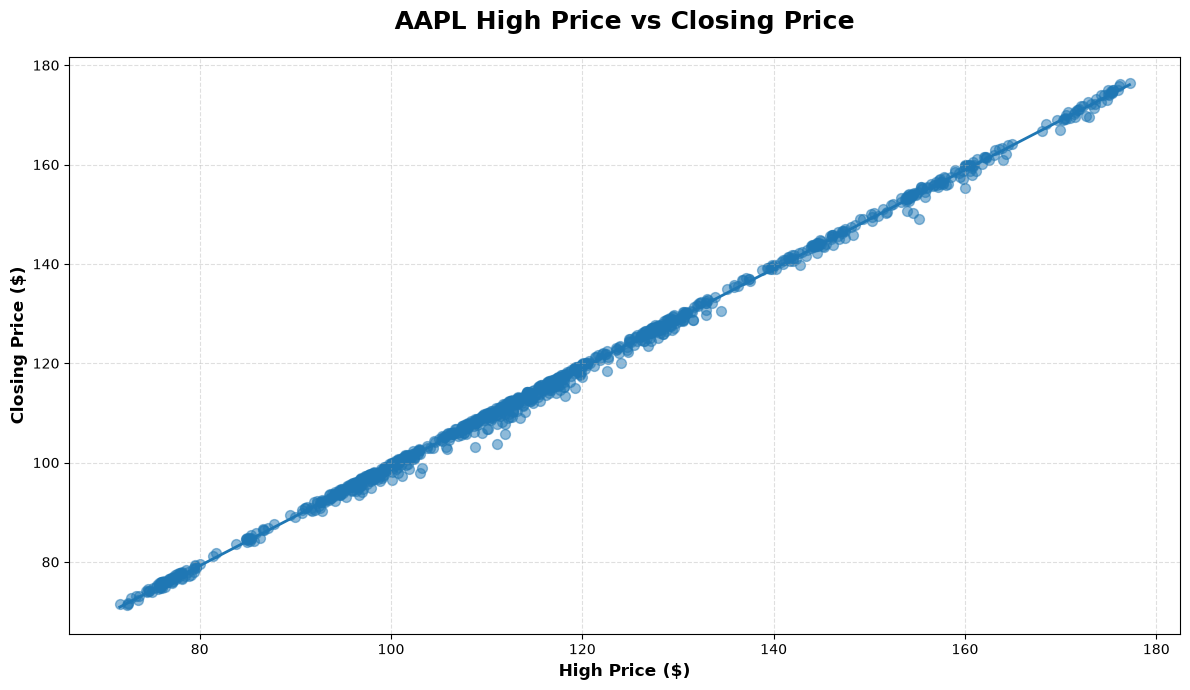

In [14]:
plt.figure(figsize=(12, 7))

sns.regplot(
    data=aapl,
    x='high',
    y='close',
    scatter_kws={
        'alpha': 0.5,
        's': 50
    },
    line_kws={
        'linewidth': 2})

# Title
plt.title(
    'AAPL High Price vs Closing Price',
    fontsize=18,
    fontweight='bold',
    pad=20)

# Axis labels
plt.xlabel(
    'High Price ($)',
    fontsize=12,
    fontweight='bold')

plt.ylabel(
    'Closing Price ($)',
    fontsize=12,
    fontweight='bold')

# Grid
plt.grid(
    True,
    linestyle='--',
    alpha=0.4)

# Layout
plt.tight_layout()

plt.savefig(
    'AAPL_high_vs_closing_price.png',
    dpi=300,
    bbox_inches='tight')

plt.show()

# Thank You 